# Python för AI - Inlämningsuppgift

## Projekt: Klassificering av Iris-blommor

I detta projekt tränas en enkel maskininlärningsmodell som kan förutsäga vilken art en Iris-blomma tillhör utifrån fyra numeriska mätvärden. Datasetet är Iris-datasetet från Scikit-learn.

## Steg 1: Problem och dataset

**Problem:** Förutsäga Iris-art baserat på blombladens och foderbladens längd och bredd.

**Dataset:** Iris-datasetet innehåller 150 observationer och fyra features: sepal length, sepal width, petal length och petal width. Målet är att klassificera varje blomma som setosa, versicolor eller virginica.

**Typ av uppgift:** Klassificering, eftersom modellen ska välja en kategori/art.

In [9]:
# Importera bibliotek
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline


In [10]:
# Ladda in datasetet
iris = load_iris()

# Skapa en DataFrame för att lättare kunna undersöka datat
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df["target"] = iris.target
df["species"] = df["target"].map({i: name for i, name in enumerate(iris.target_names)})

# Visa de första raderna
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [11]:
# Grundläggande information om datasetet
print("Antal rader och kolumner:", df.shape)
print("\nSaknade värden per kolumn:")
print(df.isnull().sum())
print("\nAntal observationer per art:")
print(df["species"].value_counts())

Antal rader och kolumner: (150, 6)

Saknade värden per kolumn:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
species              0
dtype: int64

Antal observationer per art:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


## Steg 2: Förberedelse av data

Datasetet innehåller inga saknade värden. Alla features är numeriska. Eftersom logistisk regression kan påverkas av olika skalor standardiseras de numeriska variablerna med `StandardScaler`.

In [12]:
# Välj features och målvariabel
X = df[iris.feature_names]
y = df["target"]

# Dela upp datat i träningsdata och testdata
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Träningsdata:", X_train.shape)
print("Testdata:", X_test.shape)

Träningsdata: (120, 4)
Testdata: (30, 4)


## Visualisering

Diagrammet nedan visar sambandet mellan petal length och petal width. Dessa två features verkar skilja arterna tydligt åt, vilket kan hjälpa modellen att klassificera blommorna.

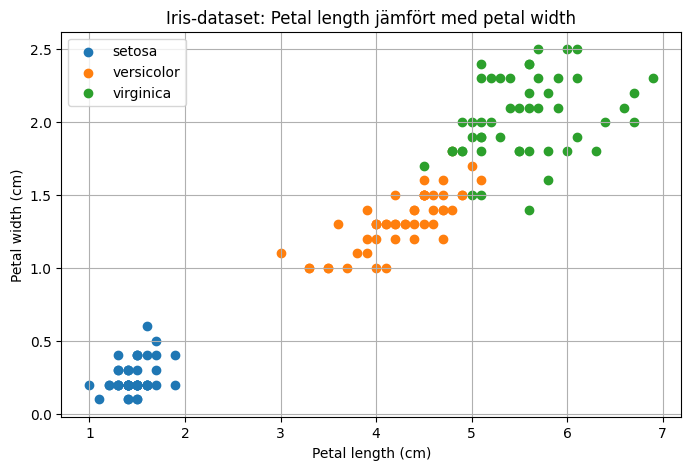

In [13]:
# Visualisering av två viktiga features
plt.figure(figsize=(8, 5))
for species_name in iris.target_names:
    subset = df[df["species"] == species_name]
    plt.scatter(subset["petal length (cm)"], subset["petal width (cm)"], label=species_name)

plt.xlabel("Petal length (cm)")
plt.ylabel("Petal width (cm)")
plt.title("Iris-dataset: Petal length jämfört med petal width")
plt.legend()
plt.grid(True)
plt.show()

## Steg 3: Träna modell

Jag använder logistisk regression eftersom det är en enkel och tydlig modell för klassificering. Modellen tränas i en pipeline tillsammans med standardisering.

In [14]:
# Skapa pipeline med standardisering och logistisk regression
model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=200, random_state=42))
])

# Träna modellen
model.fit(X_train, y_train)
print("Modellen är tränad.")

Modellen är tränad.


## Steg 4: Utvärdera modell

In [15]:
# Gör prediktioner på testdata
y_pred = model.predict(X_test)

# Utvärdera modellen
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")
print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

Accuracy: 0.93

Classification report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



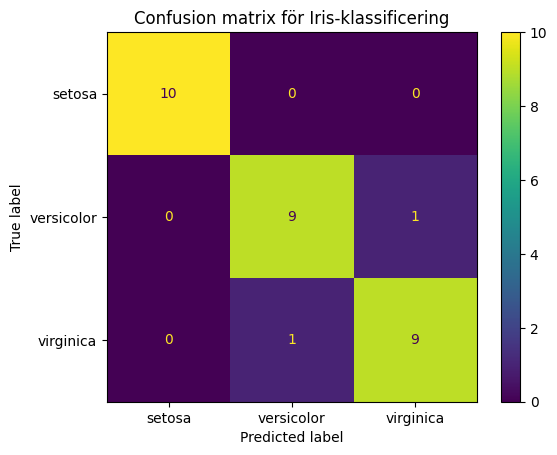

In [16]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)
display.plot()
plt.title("Confusion matrix för Iris-klassificering")
plt.show()

## Reflektion

Modellen presterar bra på testdatan. Iris-datasetet är relativt litet och tydligt, särskilt eftersom petal length och petal width skiljer arterna åt. En begränsning är att datasetet är enkelt och inte nödvändigtvis representerar alla variationer som kan finnas i verkliga miljöer. I verkligheten kan mätfel, fler arter och mer varierande data göra problemet svårare.

Möjliga förbättringar:

- Testa fler modeller, till exempel beslutsträd eller Random Forest.
- Använda korsvalidering för en mer stabil utvärdering.
- Samla in mer data om modellen skulle användas i ett verkligt system.
- Göra hyperparametertuning för att se om modellen kan förbättras ytterligare.